# ConvNeXt-Tiny 튜닝

**2단계 학습 전략**
- Phase 1 — backbone freeze, head만 학습 (빠른 초기 수렴)
- Phase 2 — backbone unfreeze, layer-wise LR decay + warmup fine-tune

**추가 기법**
- Label Smoothing 0.1 / Mixup alpha=0.4 / Gradient Clipping
- 강화 증강 (RandomCrop, RandomErasing)
- SPACE_W=2.0 (space 축 더 강조)

## 1. 설정

In [1]:
import os, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.models as tvm
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pickle
warnings.filterwarnings("ignore")

CSV_PATH   = "/home/piai/b2/PBA_AI_Project/modeling/image/space_mood_tag_captioned.csv"
IMAGE_ROOT = "/home/piai/다운로드/mood_tag/data"
SAVE_DIR   = "/home/piai/b2/PBA_AI_Project/modeling/image/saved_models"
CKPT_DIR   = os.path.join(SAVE_DIR, "checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

MODEL_NAME = "ConvNeXt-Tiny"

IMG_SIZE     = 224
BATCH_SIZE   = 8
N_FOLDS      = 5
NUM_WORKERS  = 2
EMOTION_W, VISUAL_W, SPACE_W = 1.0, 1.0, 2.0

# Phase 1: backbone freeze
P1_EPOCHS = 15
P1_LR     = 5e-4

# Phase 2: full fine-tune
P2_EPOCHS       = 50
P2_LR_HEAD      = 1e-4
P2_LR_BACKBONE  = 1e-5
WEIGHT_DECAY    = 1e-4
WARMUP_EPOCHS   = 5
LABEL_SMOOTHING = 0.1
MIXUP_ALPHA     = 0.4
GRAD_CLIP       = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(42)

Device: cuda
GPU: NVIDIA RTX A5000


/home/piai/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 데이터 로드

In [2]:
df = pd.read_csv(CSV_PATH)
for col in ["emotion", "visual", "space"]:
    df[col] = df[col].str.strip().str.lower()

def find_image_path(row_id):
    for ext in ["jpg", "jpeg", "png", "webp"]:
        p = os.path.join(IMAGE_ROOT, f"image_{int(row_id):03d}.{ext}")
        if os.path.exists(p): return p
    return None

df["full_path"] = df["id"].apply(find_image_path)
df = df.dropna(subset=["full_path"]).reset_index(drop=True)
print(f"학습 데이터: {len(df)}장")

emotion_le = LabelEncoder(); visual_le = LabelEncoder(); space_le = LabelEncoder()
df["emotion_idx"] = emotion_le.fit_transform(df["emotion"])
df["visual_idx"]  = visual_le.fit_transform(df["visual"])
df["space_idx"]   = space_le.fit_transform(df["space"])

NUM_EMOTION = df["emotion_idx"].nunique()
NUM_VISUAL  = df["visual_idx"].nunique()
NUM_SPACE   = df["space_idx"].nunique()
print(f"emotion ({NUM_EMOTION}): {list(emotion_le.classes_)}")
print(f"visual  ({NUM_VISUAL}):  {list(visual_le.classes_)}")
print(f"space   ({NUM_SPACE}):   {list(space_le.classes_)}")

학습 데이터: 294장
emotion (3): ['chic', 'cozy', 'lively']
visual  (4):  ['bright', 'cool', 'dark', 'warm']
space   (3):   ['compact', 'private', 'spacious']


## 3. Dataset & 강화 Augmentation

In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])
valid_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class SpaceDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["full_path"]).convert("RGB")
        if self.transform: img = self.transform(img)
        return {
            "image":   img,
            "emotion": torch.tensor(int(row["emotion_idx"]), dtype=torch.long),
            "visual":  torch.tensor(int(row["visual_idx"]),  dtype=torch.long),
            "space":   torch.tensor(int(row["space_idx"]),   dtype=torch.long),
        }

print("Dataset 정의 완료")

Dataset 정의 완료


## 4. 모델 정의

In [4]:
class MultiHeadClassifier(nn.Module):
    def __init__(self, backbone, backbone_out_dim, num_emotion, num_visual, num_space, dropout=0.4):
        super().__init__()
        self.backbone = backbone
        self.neck = nn.Sequential(
            nn.Linear(backbone_out_dim, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),              nn.GELU(), nn.Dropout(dropout * 0.5),
        )
        self.emotion_head = nn.Linear(256, num_emotion)
        self.visual_head  = nn.Linear(256, num_visual)
        self.space_head   = nn.Linear(256, num_space)

    def forward(self, x):
        f = self.backbone(x)
        if f.dim() > 2: f = f.flatten(1)
        f = self.neck(f)
        return self.emotion_head(f), self.visual_head(f), self.space_head(f)

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

def build_convnext():
    m = tvm.convnext_tiny(weights=tvm.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    dim = m.classifier[2].in_features
    m.classifier = nn.Identity()
    return MultiHeadClassifier(m, dim, NUM_EMOTION, NUM_VISUAL, NUM_SPACE)

print("모델 정의 완료")

모델 정의 완료


## 5. 학습 헬퍼

In [5]:
def make_weights(labels, n):
    c = np.maximum(np.bincount(labels, minlength=n).astype(float), 1)
    return torch.tensor(len(labels) / (n * c), dtype=torch.float32).to(DEVICE)

def exact_match(et, vt, st, ep, vp, sp):
    et,vt,st,ep,vp,sp = (np.array(x) for x in [et,vt,st,ep,vp,sp])
    return float(((et==ep)&(vt==vp)&(st==sp)).mean())

def mixup_batch(imgs, le, lv, ls, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    return lam*imgs+(1-lam)*imgs[idx], le, lv, ls, (le[idx], lv[idx], ls[idx], lam)

def mixup_loss(crit, pred, ya, yb, lam):
    return lam*crit(pred, ya) + (1-lam)*crit(pred, yb)

def train_phase1_epoch(model, loader, optimizer, criteria):
    model.train(); ce, cv, cs = criteria
    for b in loader:
        img=b["image"].to(DEVICE); emo=b["emotion"].to(DEVICE)
        vis=b["visual"].to(DEVICE); spa=b["space"].to(DEVICE)
        optimizer.zero_grad()
        eo, vo, so = model(img)
        loss = EMOTION_W*ce(eo,emo)+VISUAL_W*cv(vo,vis)+SPACE_W*cs(so,spa)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

def train_phase2_epoch(model, loader, optimizer, criteria):
    model.train(); ce, cv, cs = criteria
    for b in loader:
        img=b["image"].to(DEVICE); emo=b["emotion"].to(DEVICE)
        vis=b["visual"].to(DEVICE); spa=b["space"].to(DEVICE)
        img, emo, vis, spa, mix = mixup_batch(img, emo, vis, spa, MIXUP_ALPHA)
        optimizer.zero_grad()
        eo, vo, so = model(img)
        if mix is not None:
            eb,vb,sb,lam = mix
            loss = EMOTION_W*mixup_loss(ce,eo,emo,eb,lam)+VISUAL_W*mixup_loss(cv,vo,vis,vb,lam)+SPACE_W*mixup_loss(cs,so,spa,sb,lam)
        else:
            loss = EMOTION_W*ce(eo,emo)+VISUAL_W*cv(vo,vis)+SPACE_W*cs(so,spa)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

@torch.no_grad()
def valid_epoch(model, loader, criteria):
    model.eval(); ce, cv, cs = criteria; total = 0
    et,ep,vt,vp,st,sp = [],[],[],[],[],[]
    for b in loader:
        img=b["image"].to(DEVICE); emo=b["emotion"].to(DEVICE)
        vis=b["visual"].to(DEVICE); spa=b["space"].to(DEVICE)
        eo, vo, so = model(img)
        total += (EMOTION_W*ce(eo,emo)+VISUAL_W*cv(vo,vis)+SPACE_W*cs(so,spa)).item()
        et.extend(emo.cpu().numpy()); ep.extend(eo.argmax(1).cpu().numpy())
        vt.extend(vis.cpu().numpy()); vp.extend(vo.argmax(1).cpu().numpy())
        st.extend(spa.cpu().numpy()); sp.extend(so.argmax(1).cpu().numpy())
    return {
        "loss": total/len(loader),
        "emotion_f1":  f1_score(et,ep,average="macro",zero_division=0),
        "visual_f1":   f1_score(vt,vp,average="macro",zero_division=0),
        "space_f1":    f1_score(st,sp,average="macro",zero_division=0),
        "exact_match": exact_match(et,vt,st,ep,vp,sp),
        "emotion_true":et,"emotion_pred":ep,
        "visual_true":vt,"visual_pred":vp,
        "space_true":st,"space_pred":sp,
    }

print("헬퍼 함수 정의 완료")

헬퍼 함수 정의 완료


## 6. 2단계 튜닝 함수 (5-Fold CV)

In [6]:
def run_kfold_tuned():
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    strat_key = (df["emotion_idx"].astype(str)+"_"+df["visual_idx"].astype(str)+"_"+df["space_idx"].astype(str)).values
    fold_results = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(df, strat_key)):
        print(f"\n{'='*50}\n[Fold {fold+1}/{N_FOLDS}]")
        tr_df = df.iloc[tr_idx].reset_index(drop=True)
        vl_df = df.iloc[val_idx].reset_index(drop=True)
        criteria = (
            nn.CrossEntropyLoss(weight=make_weights(tr_df["emotion_idx"].values,NUM_EMOTION),label_smoothing=LABEL_SMOOTHING),
            nn.CrossEntropyLoss(weight=make_weights(tr_df["visual_idx"].values, NUM_VISUAL), label_smoothing=LABEL_SMOOTHING),
            nn.CrossEntropyLoss(weight=make_weights(tr_df["space_idx"].values,  NUM_SPACE),  label_smoothing=LABEL_SMOOTHING),
        )
        tr_loader = DataLoader(SpaceDataset(tr_df,train_tf),batch_size=BATCH_SIZE,shuffle=True, num_workers=NUM_WORKERS,pin_memory=True)
        vl_loader = DataLoader(SpaceDataset(vl_df,valid_tf),batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=True)
        model = build_convnext().to(DEVICE)
        best_score, best_metrics = -1.0, None

        # Phase 1: backbone freeze
        print(f"  Phase 1 — freeze {P1_EPOCHS} epochs")
        model.freeze_backbone()
        opt1 = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=P1_LR, weight_decay=WEIGHT_DECAY)
        sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=P1_EPOCHS)
        for epoch in range(1, P1_EPOCHS+1):
            train_phase1_epoch(model, tr_loader, opt1, criteria)
            sch1.step()
            val = valid_epoch(model, vl_loader, criteria)
            score = (val["emotion_f1"]+val["visual_f1"]+val["space_f1"])/3
            if score > best_score: best_score, best_metrics = score, val
        print(f"    best mean_f1={best_score:.4f}")

        # Phase 2: full fine-tune
        print(f"  Phase 2 — unfreeze {P2_EPOCHS} epochs")
        model.unfreeze_backbone()
        opt2 = torch.optim.AdamW([
            {"params": list(model.backbone.parameters()),                                                                     "lr": P2_LR_BACKBONE},
            {"params": list(model.neck.parameters())+list(model.emotion_head.parameters())+
                       list(model.visual_head.parameters())+list(model.space_head.parameters()), "lr": P2_LR_HEAD},
        ], weight_decay=WEIGHT_DECAY)
        warmup_s = torch.optim.lr_scheduler.LinearLR(opt2, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
        cosine_s = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=P2_EPOCHS-WARMUP_EPOCHS)
        sch2 = torch.optim.lr_scheduler.SequentialLR(opt2, [warmup_s, cosine_s], milestones=[WARMUP_EPOCHS])
        for epoch in range(1, P2_EPOCHS+1):
            train_phase2_epoch(model, tr_loader, opt2, criteria)
            sch2.step()
            val = valid_epoch(model, vl_loader, criteria)
            score = (val["emotion_f1"]+val["visual_f1"]+val["space_f1"])/3
            if score > best_score: best_score, best_metrics = score, val
            if epoch % 10 == 0:
                print(f"    epoch {epoch:3d}/{P2_EPOCHS} | mean_f1={score:.4f}  exact={val['exact_match']:.4f}")

        print(f"  Fold {fold+1} 완료 → mean_f1={best_score:.4f}  exact={best_metrics['exact_match']:.4f}")
        fold_results.append(best_metrics)

    return {
        "model":          f"{MODEL_NAME} (Tuned)",
        "emotion_f1":     np.mean([r["emotion_f1"]  for r in fold_results]),
        "visual_f1":      np.mean([r["visual_f1"]   for r in fold_results]),
        "space_f1":       np.mean([r["space_f1"]    for r in fold_results]),
        "exact_match":    np.mean([r["exact_match"] for r in fold_results]),
        "mean_f1":        np.mean([(r["emotion_f1"]+r["visual_f1"]+r["space_f1"])/3 for r in fold_results]),
        "emotion_f1_std": np.std([r["emotion_f1"]  for r in fold_results]),
        "visual_f1_std":  np.std([r["visual_f1"]   for r in fold_results]),
        "space_f1_std":   np.std([r["space_f1"]    for r in fold_results]),
        "fold_results":   fold_results,
    }

print("run_kfold_tuned 정의 완료")

run_kfold_tuned 정의 완료


## 7. 튜닝 실행

In [7]:
TUNE_CKPT = os.path.join(CKPT_DIR, "ConvNeXt-Tiny_tuned_result.pkl")

if os.path.exists(TUNE_CKPT):
    with open(TUNE_CKPT, "rb") as f:
        tuned_result = pickle.load(f)
    print(f"[스킵] 튜닝 체크포인트 로드 | mean_f1={tuned_result['mean_f1']:.4f}")
else:
    tuned_result = run_kfold_tuned()
    with open(TUNE_CKPT, "wb") as f:
        pickle.dump(tuned_result, f)
    print(f"\n저장 완료: {TUNE_CKPT}")


[Fold 1/5]
  Phase 1 — freeze 15 epochs
    best mean_f1=0.5628
  Phase 2 — unfreeze 50 epochs
    epoch  10/50 | mean_f1=0.5475  exact=0.1525
    epoch  20/50 | mean_f1=0.5182  exact=0.1525
    epoch  30/50 | mean_f1=0.5269  exact=0.1525
    epoch  40/50 | mean_f1=0.5324  exact=0.1695
    epoch  50/50 | mean_f1=0.5444  exact=0.1695
  Fold 1 완료 → mean_f1=0.5628  exact=0.1525

[Fold 2/5]
  Phase 1 — freeze 15 epochs
    best mean_f1=0.4221
  Phase 2 — unfreeze 50 epochs
    epoch  10/50 | mean_f1=0.4871  exact=0.1864
    epoch  20/50 | mean_f1=0.4974  exact=0.1695
    epoch  30/50 | mean_f1=0.4829  exact=0.1525
    epoch  40/50 | mean_f1=0.5032  exact=0.1695
    epoch  50/50 | mean_f1=0.5076  exact=0.1695
  Fold 2 완료 → mean_f1=0.5194  exact=0.1695

[Fold 3/5]
  Phase 1 — freeze 15 epochs
    best mean_f1=0.5321
  Phase 2 — unfreeze 50 epochs
    epoch  10/50 | mean_f1=0.5543  exact=0.2034
    epoch  20/50 | mean_f1=0.5796  exact=0.2542
    epoch  30/50 | mean_f1=0.5906  exact=0.2881
  

## 8. 베이스라인 vs 튜닝 비교

지표                      baseline       tuned     delta
-------------------------------------------------------
emotion_f1                0.6237      0.5911  ▼0.0326
visual_f1                 0.6024      0.5511  ▼0.0513
space_f1                  0.5491      0.5501  ▲0.0010
exact_match               0.2586      0.1938  ▼0.0648
mean_f1                   0.5917      0.5641  ▼0.0276


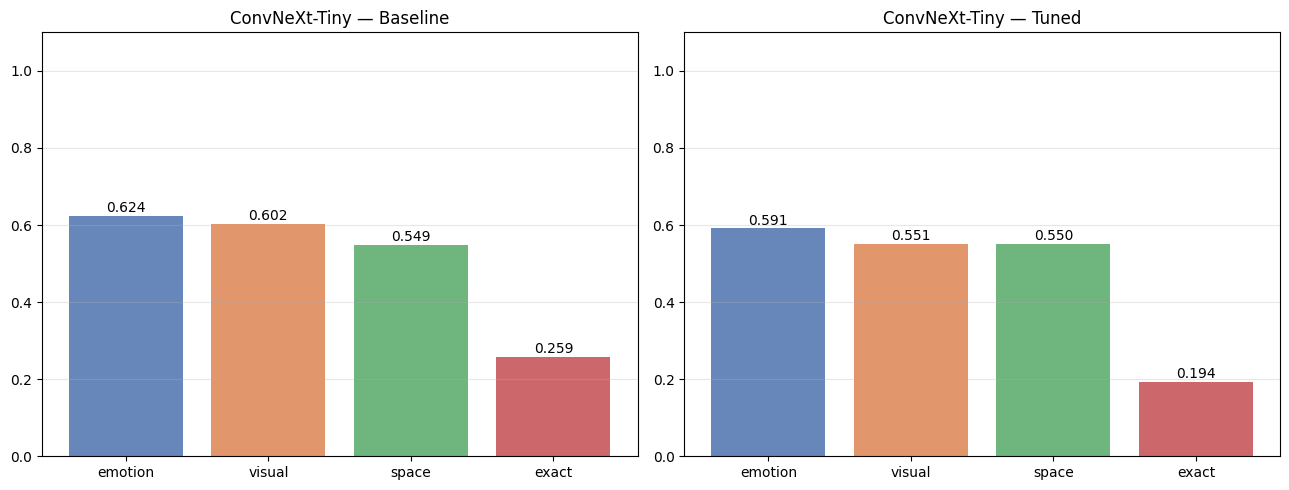

In [8]:
baseline_ckpt = os.path.join(CKPT_DIR, "ConvNeXt-Tiny_result.pkl")
if os.path.exists(baseline_ckpt):
    with open(baseline_ckpt, "rb") as f:
        baseline_result = pickle.load(f)

    metrics = ["emotion_f1","visual_f1","space_f1","exact_match","mean_f1"]
    print(f"{'지표':20s}  {'baseline':>10s}  {'tuned':>10s}  {'delta':>8s}")
    print("-" * 55)
    for m in metrics:
        b = baseline_result[m]; t = tuned_result[m]
        arrow = "▲" if t > b else "▼"
        print(f"{m:20s}  {b:10.4f}  {t:10.4f}  {arrow}{abs(t-b):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (label, result) in zip(axes, [("Baseline", baseline_result), ("Tuned", tuned_result)]):
        vals = [result[m] for m in ["emotion_f1","visual_f1","space_f1","exact_match"]]
        bars = ax.bar(["emotion","visual","space","exact"], vals,
                      color=["#4C72B0","#DD8452","#55A868","#C44E52"], alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f"{v:.3f}", ha="center", fontsize=10)
        ax.set_ylim(0, 1.1); ax.set_title(f"{MODEL_NAME} — {label}"); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "tune_comparison.png"), dpi=150)
    plt.show()
else:
    print("베이스라인 없음 — train_compare.ipynb 먼저 실행하세요")

## 9. 전체 데이터 최종 학습 & 저장

In [9]:
print(f"전체 {len(df)}장으로 최종 모델 학습")
criteria_final = (
    nn.CrossEntropyLoss(weight=make_weights(df["emotion_idx"].values,NUM_EMOTION),label_smoothing=LABEL_SMOOTHING),
    nn.CrossEntropyLoss(weight=make_weights(df["visual_idx"].values, NUM_VISUAL), label_smoothing=LABEL_SMOOTHING),
    nn.CrossEntropyLoss(weight=make_weights(df["space_idx"].values,  NUM_SPACE),  label_smoothing=LABEL_SMOOTHING),
)
full_loader = DataLoader(SpaceDataset(df, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
final_model = build_convnext().to(DEVICE)

# Phase 1
final_model.freeze_backbone()
opt1 = torch.optim.AdamW(filter(lambda p: p.requires_grad, final_model.parameters()), lr=P1_LR, weight_decay=WEIGHT_DECAY)
sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=P1_EPOCHS)
for epoch in tqdm(range(1, P1_EPOCHS+1), desc="Phase 1 (freeze)"):
    train_phase1_epoch(final_model, full_loader, opt1, criteria_final)
    sch1.step()

# Phase 2
final_model.unfreeze_backbone()
opt2 = torch.optim.AdamW([
    {"params": list(final_model.backbone.parameters()),                                                                           "lr": P2_LR_BACKBONE},
    {"params": list(final_model.neck.parameters())+list(final_model.emotion_head.parameters())+
               list(final_model.visual_head.parameters())+list(final_model.space_head.parameters()), "lr": P2_LR_HEAD},
], weight_decay=WEIGHT_DECAY)
warmup_s = torch.optim.lr_scheduler.LinearLR(opt2, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
cosine_s = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=P2_EPOCHS-WARMUP_EPOCHS)
sch2 = torch.optim.lr_scheduler.SequentialLR(opt2, [warmup_s, cosine_s], milestones=[WARMUP_EPOCHS])
for epoch in tqdm(range(1, P2_EPOCHS+1), desc="Phase 2 (fine-tune)"):
    train_phase2_epoch(final_model, full_loader, opt2, criteria_final)
    sch2.step()

save_path = os.path.join(SAVE_DIR, "final_ConvNeXt-Tiny_tuned.pt")
torch.save({
    "model_state_dict": final_model.state_dict(),
    "model_name":       MODEL_NAME,
    "emotion_classes":  list(emotion_le.classes_),
    "visual_classes":   list(visual_le.classes_),
    "space_classes":    list(space_le.classes_),
    "config": {"img_size": IMG_SIZE, "num_emotion": NUM_EMOTION, "num_visual": NUM_VISUAL, "num_space": NUM_SPACE},
}, save_path)
print(f"\n최종 모델 저장: {save_path}")

전체 294장으로 최종 모델 학습


Phase 2 (fine-tune): 100%|██████████| 50/50 [02:18<00:00,  2.78s/it]



최종 모델 저장: /home/piai/b2/PBA_AI_Project/modeling/image/saved_models/final_ConvNeXt-Tiny_tuned.pt
